# Algoritmos de optimización - Proyecto
**Autores**:
- Adrián García López
- Daniel León Romero

**Url**: https://github.com/adri14gl/Algoritmos_de_Optimizacion_VIU/tree/main/Proyecto_Talent_Scheduling<br>
**Problema**:
>**1. Sesiones de doblaje**<br>
>2. Organizar los horarios de partidos de La Liga<br>
>3. Combinar cifras y operaciones

**Descripción del problema**:

>Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los datos son:
>
>Número de actores:  10
>
>Número de tomas :   30
>
>Actores/Tomas :		https://bit.ly/36D8IuK
>
>- 1 indica que el actor participa en la toma
>- 0 en caso contrario





# Índice
1. [Carga y presentación de los datos](#1-carga)
2. [Funciones auxiliares comunes](#2-funciones)
3. [Solver de Google OR-Tools](#3-solver)
4. [Fuerza Bruta](#4-fuerza-bruta)
5. [Brunch & Bound](#5-brunch-bound)
6. [Metaheurística: GRASP](#6-grasp)
7. [Conclusiones](#7-conclusiones)
8. [Preguntas del proyecto](#8-preguntas)
9. [Anexo: Prompts](#9-prompts)

## 1.- Carga y presentación de los datos <a id='1-carga'></a>

En primer lugar se lleva a cabo las operaciones preliminares para la resolución del problema: 
- Importación de librerías necesarias
- Carga y procesamiento de los datos
- Análisis preliminar y presentación de los datos

In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
import time

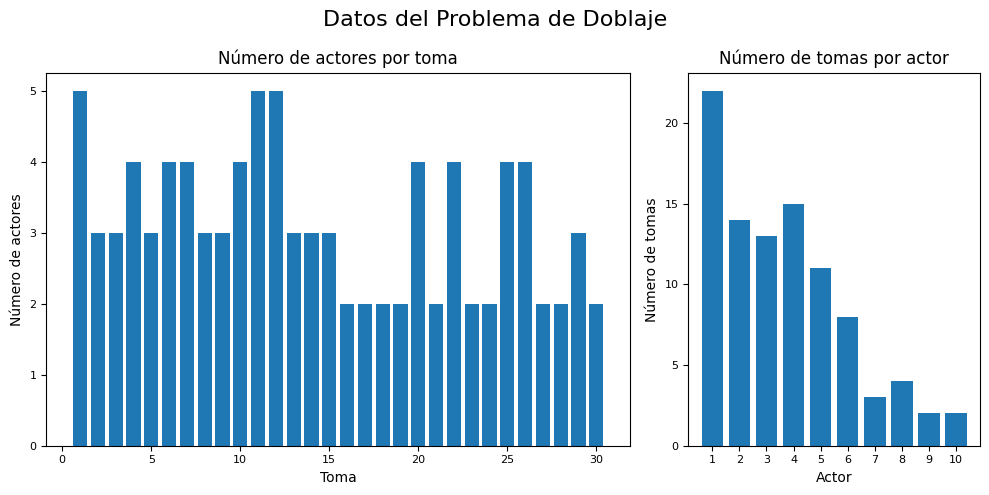

(1, [1, 1, 1, 1, 1, 0, 0, 0, 0, 0])
(2, [0, 0, 1, 1, 1, 0, 0, 0, 0, 0])
(3, [0, 1, 0, 0, 1, 0, 1, 0, 0, 0])
(4, [1, 1, 0, 0, 0, 0, 1, 1, 0, 0])
(5, [0, 1, 0, 1, 0, 0, 0, 1, 0, 0])
(6, [1, 1, 0, 1, 1, 0, 0, 0, 0, 0])
(7, [1, 1, 0, 1, 1, 0, 0, 0, 0, 0])
(8, [1, 1, 0, 0, 0, 1, 0, 0, 0, 0])
(9, [1, 1, 0, 1, 0, 0, 0, 0, 0, 0])
(10, [1, 1, 0, 0, 0, 1, 0, 0, 1, 0])
(11, [1, 1, 1, 0, 1, 0, 0, 1, 0, 0])
(12, [1, 1, 1, 1, 0, 1, 0, 0, 0, 0])
(13, [1, 0, 0, 1, 1, 0, 0, 0, 0, 0])
(14, [1, 0, 1, 0, 0, 1, 0, 0, 0, 0])
(15, [1, 1, 0, 0, 0, 0, 1, 0, 0, 0])
(16, [0, 0, 0, 1, 0, 0, 0, 0, 0, 1])
(17, [1, 0, 1, 0, 0, 0, 0, 0, 0, 0])
(18, [0, 0, 1, 0, 0, 1, 0, 0, 0, 0])
(19, [1, 0, 1, 0, 0, 0, 0, 0, 0, 0])
(20, [1, 0, 1, 1, 1, 0, 0, 0, 0, 0])
(21, [0, 0, 0, 0, 0, 1, 0, 1, 0, 0])
(22, [1, 1, 1, 1, 0, 0, 0, 0, 0, 0])
(23, [1, 0, 1, 0, 0, 0, 0, 0, 0, 0])
(24, [0, 0, 1, 0, 0, 1, 0, 0, 0, 0])
(25, [1, 1, 0, 1, 0, 0, 0, 0, 0, 1])
(26, [1, 0, 1, 0, 1, 0, 0, 0, 1, 0])
(27, [0, 0, 0, 1, 1, 0, 0, 0, 0, 0])
(28, [1, 0

In [2]:
# URL de descarga
url_datos_problema_doblaje = "https://docs.google.com/spreadsheets/d/1Ipn6IrbQP4ax8zOnivdBIw2lN0JISkJG4fXndYd27U0/edit?gid=0#gid=0"
url_csv = url_datos_problema_doblaje.replace('/edit?gid=0#gid=0', '/export?format=csv')

# Cargar los datos
df = pd.read_csv(url_csv, index_col=0, header=1)
# Eliminar las dos columnas últimas (vacía y total de actores por toma)
df = df.drop(df.columns[[10,11]], axis=1)
# Eliminar las dos últimas filas (vacía y total de tomas por actor)
df = df.drop(df.index[[30,31]])
# Convertir los datos a enteros
df = df.convert_dtypes()
# Convertir el índice a entero
df.index = df.index.astype(int)

# Tabla suma de actores por toma
numero_actores_por_toma = df.sum(axis=1)
# Asignar el nombre 'Nº Actores' a la nueva columna
numero_actores_por_toma = numero_actores_por_toma.to_frame(name='Nº Actores')

# Tabla suma de tomas por actor
numero_tomas_por_actor = df.sum(axis=0)
# Asignar el nombre 'Nº Tomas' a la nueva columna
numero_tomas_por_actor = numero_tomas_por_actor.to_frame(name='Nº Tomas')

# Crear la figura y los subplots
fig, axes = plt.subplots(1,2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle("Datos del Problema de Doblaje", fontsize=16)

# Construcción de los subplot
axes[0].bar(numero_actores_por_toma.index, numero_actores_por_toma['Nº Actores'])
axes[1].bar(numero_tomas_por_actor.index, numero_tomas_por_actor['Nº Tomas'])

# Etiquetas y título del diagrama
axes[0].set_title("Número de actores por toma")
axes[0].set_xlabel("Toma")
axes[0].set_ylabel("Número de actores")
axes[0].tick_params(axis='x', labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].set_title("Número de tomas por actor")
axes[1].set_xlabel("Actor")
axes[1].set_ylabel("Número de tomas")
axes[1].tick_params(axis='x', labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

# Configuración y visualización
fig.tight_layout()
plt.show()

# Convertir a un diccionario.
diccionario_tomas = df.T.to_dict(orient='list')
for toma in diccionario_tomas.items():
  print(toma)

## 2.- Funciones auxiliares comunes <a id='2-funciones'></a>
En esta sección se incluyen funciones de apoyo que posteriormente serán utilizadas por los algoritmos destinados a resolver el problema.

In [3]:
# Función de coste para una sesión
def coste_sesion(sesion):
  actores = set()
  for toma in sesion:
    for i in range(len(diccionario_tomas[toma])):
      if diccionario_tomas[toma][i]:
        actores.add(i)
  return len(actores)

# Función de coste para la solucion (lista de sesiones)
def coste_solucion(solucion):
  sesiones = 0
  for sesion in range(len(solucion)):
    sesiones += coste_sesion(solucion[sesion])
  return sesiones

# Imprimir una sesión
def imprimir_sesion(n, sesion):
  actores = set()
  for toma in sesion:
    for actor in range(len(diccionario_tomas[toma])):
      if diccionario_tomas[toma][actor]:
        actores.add(actor + 1)# La lista empieza en 0 y los actores en 1
  print("Día ", n, ":", sesion, " - Actores: ", actores, " - Coste: ", coste_sesion(sesion))

# Imprimir solución completa
def imprimir_solucion(solucion):
  print("Solucion:")
  for sesion in range(len(solucion)):
    imprimir_sesion(sesion + 1, solucion[sesion])

# Solución válida
# Para que sea una solución válida, el número de tomas de la solución tiene que
# ser igual al número de tomas del problema y todas las tomas tienen que ser
# diferentes.
def solucion_valida(solucion):
  tomas_planificadas = list()
  tomas_problema = len(diccionario_tomas)
  for sesion in solucion:
    for toma in sesion:
      tomas_planificadas.append(toma)
  if len(tomas_planificadas) == tomas_problema and len(set(tomas_planificadas)) == tomas_problema:
    return True
  else:
    return False

# Copiar solución
# Al tratarse de una lista de listas, con la asignación no se copia el contenido
# de las sublistas, por lo que es necesario utiliza la función copy()
def copiar_solucion(solucion):
  mejor_solucion = []
  for sesion in solucion:
    mejor_solucion.append(sesion.copy())
  return mejor_solucion

## 3.- Estándar industrial: Solver de Google OR-Tools <a id='3-solver'></a>

Con el objetivo de establecer de antemano el valor objetivo al que deben aspirar nuestros propios algoritmos, ejecutamos un solver comercial. Puesto que su uso no está entre los contenidos del curso lo programamos con ayuda de Gemini (prompt en Anexo). Tras ejecutarlo, vemos que el valor óptimo del problema son **27 unidades monetarias**.

In [1]:
from ortools.sat.python import cp_model

def solver_comercial (tomas_actores_dict, imprimir=True):
    """
    Resuelve el problema de programación de rodaje utilizando un diccionario
    con codificación binaria (one-hot) de los actores por toma.
    """
    model = cp_model.CpModel()

    # --- 1. PREPROCESAMIENTO DE DATOS ---
    tomas_ids = sorted(tomas_actores_dict.keys()) # [1, 2, ..., 30]
    num_tomas = len(tomas_ids)
    max_tomas_dia = 6
    
    # El número de actores viene dado por la longitud de la lista binaria
    # Asumimos que la primera toma tiene el formato correcto para medirlo
    num_actores = len(tomas_actores_dict[tomas_ids[0]]) 
    actores_ids = list(range(1, num_actores + 1)) # Actores del 1 al 10
    
    # Pre-calcular qué tomas requieren a qué actor
    # tomas_por_actor[actor_id] = [toma_id_A, toma_id_B...]
    tomas_por_actor = {a: [] for a in actores_ids}
    
    for t_id in tomas_ids:
        lista_binaria = tomas_actores_dict[t_id]
        for idx, valor in enumerate(lista_binaria):
            if valor == 1:
                actor_id = idx + 1 # El índice 0 corresponde al actor 1
                tomas_por_actor[actor_id].append(t_id)

    # Estimación de días:
    num_dias = num_tomas 
    dias = range(num_dias)

    # --- 2. VARIABLES DE DECISIÓN ---
    
    # x[t, d] = 1 si la toma 't' se asigna al día 'd'
    x = {}
    for t in tomas_ids:
        for d in dias:
            x[t, d] = model.NewBoolVar(f'toma_{t}_dia_{d}')

    # y[a, d] = 1 si el actor 'a' trabaja el día 'd'
    y = {}
    for a in actores_ids:
        for d in dias:
            y[a, d] = model.NewBoolVar(f'actor_{a}_dia_{d}')

    # z[d] = 1 si el día 'd' se utiliza
    dia_usado = [model.NewBoolVar(f'dia_usado_{d}') for d in dias]

    # --- 3. RESTRICCIONES ---

    # A. Cada toma debe asignarse a EXACTAMENTE un día.
    for t in tomas_ids:
        model.Add(sum(x[t, d] for d in dias) == 1)

    # B. Capacidad máxima por día (Max 6 tomas).
    for d in dias:
        model.Add(sum(x[t, d] for t in tomas_ids) <= max_tomas_dia)

    # C. Vincular Actores a Días.
    for a in actores_ids:
        tomas_de_este_actor = tomas_por_actor[a]
        for d in dias:
            for t in tomas_de_este_actor:
                model.Add(y[a, d] >= x[t, d])

    # D. Romper simetrías para acelerar.
    for d in range(num_dias - 1):
        model.Add(dia_usado[d] >= dia_usado[d+1])
    
    # Vincular x con dia_usado
    for d in dias:
        model.Add(sum(x[t, d] for t in tomas_ids) > 0).OnlyEnforceIf(dia_usado[d])
        model.Add(sum(x[t, d] for t in tomas_ids) == 0).OnlyEnforceIf(dia_usado[d].Not())

    # --- 4. FUNCIÓN OBJETIVO ---
    coste_total = sum(y[a, d] for a in actores_ids for d in dias)
    model.Minimize(coste_total)

    # --- 5. RESOLUCIÓN ---
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60.0 # He subido un poco el tiempo por si acaso
    
    estado = solver.Solve(model)

    if imprimir == True:
        # --- 6. IMPRIMIR RESULTADOS ---
        if estado == cp_model.OPTIMAL or estado == cp_model.FEASIBLE:
            print(f"Estado de la solución: {solver.StatusName(estado)}")
            print(f"Coste Total Mínimo (Días-Actor a pagar): {solver.ObjectiveValue()}")
            print("-" * 40)
            
            schedule = {}
            for d in dias:
                tomas_hoy = []
                for t in tomas_ids:
                    if solver.Value(x[t, d]) == 1:
                        tomas_hoy.append(t)
                
                if tomas_hoy:
                    schedule[d] = tomas_hoy
            
            # Imprimir agenda detallada
            dias_activos = 0
            for d in sorted(schedule.keys()):
                dias_activos += 1
                tomas = schedule[d]
                actores_hoy = set()
                
                # Extraemos los actores de las tomas de hoy usando el diccionario
                for t in tomas:
                    lista_binaria = tomas_actores_dict[t]
                    for idx, valor in enumerate(lista_binaria):
                        if valor == 1:
                            actores_hoy.add(idx + 1)
                
                lista_actores_str = [str(a) for a in sorted(actores_hoy)]
                print(f"DÍA {dias_activos}:")
                print(f"  Tomas a rodar: {tomas}")
                print(f"  Actores citados ({len(actores_hoy)}): {', '.join(lista_actores_str)}")
                print(f"  Carga de trabajo: {len(tomas)}/6 tomas")
                print("-" * 20)
        else:
            print("No se encontró solución.")
    else:
        return (solver.ObjectiveValue())

In [5]:
solver_comercial(diccionario_tomas)

Estado de la solución: FEASIBLE
Coste Total Mínimo (Días-Actor a pagar): 27.0
----------------------------------------
DÍA 1:
  Tomas a rodar: [14, 17, 18, 19, 23, 24]
  Actores citados (3): 1, 3, 6
  Carga de trabajo: 6/6 tomas
--------------------
DÍA 2:
  Tomas a rodar: [9, 10, 12, 16, 22, 25]
  Actores citados (7): 1, 2, 3, 4, 6, 9, 10
  Carga de trabajo: 6/6 tomas
--------------------
DÍA 3:
  Tomas a rodar: [13, 20, 26, 27, 28, 30]
  Actores citados (5): 1, 3, 4, 5, 9
  Carga de trabajo: 6/6 tomas
--------------------
DÍA 4:
  Tomas a rodar: [3, 4, 8, 15, 21, 29]
  Actores citados (6): 1, 2, 5, 6, 7, 8
  Carga de trabajo: 6/6 tomas
--------------------
DÍA 5:
  Tomas a rodar: [1, 2, 5, 6, 7, 11]
  Actores citados (6): 1, 2, 3, 4, 5, 8
  Carga de trabajo: 6/6 tomas
--------------------


## 4.- Exploración exhaustiva: Fuerza Bruta <a id='4-fuerza-bruta'></a>

Si bien para un tamaño de 30 nuestro problema es inabordable a efectos prácticos por fuerza bruta, desarrollamos un algoritmo que, para tamaños menores del problema, permitiría encontrar la solución óptima tras la exploración exhaustiva del espacio de soluciones.

In [ ]:
# Fuerza bruta

def fuerza_bruta(numero_toma_actual, solucion_actual, mejor_solucion, mejor_solucion_coste):
  # CASO BASE: Se han planificado todas las tomas
  if numero_toma_actual == len(diccionario_tomas): 
    coste_solucion_actual = coste_solucion(solucion_actual)
    if coste_solucion_actual < mejor_solucion_coste:
      mejor_solucion_coste = coste_solucion_actual
      mejor_solucion = copiar_solucion(solucion_actual)
      # Imprimir la mejor solucion y su coste
      print("Mejor solución encontrada:")
      imprimir_solucion(mejor_solucion)
      print("Coste: ", mejor_solucion_coste)
    return mejor_solucion, mejor_solucion_coste

  # Orden con el que se seleccionan las tomas. El orden definido en el problema
  lista_tomas = list(diccionario_tomas.keys())

  # Seleccionamos la siguiente toma a añadir en la planificación
  toma_actual = lista_tomas[numero_toma_actual]

  # CASO 1: Recorre la lista de sesiones para añadir la toma actual en una sesión incompleta
  for sesion in solucion_actual:
    if len(sesion) < 6:
      sesion.append(toma_actual)
      mejor_solucion, mejor_solucion_coste = fuerza_bruta(numero_toma_actual + 1, solucion_actual, mejor_solucion, mejor_solucion_coste)
      # Restaurar la solución, elimina la toma actual de la sesión actual
      sesion.pop()

  # CASO 2: Se crea una nueva sesión y la toma actual es la primera toma
  solucion_actual.append([toma_actual])
  mejor_solucion, mejor_solucion_coste = fuerza_bruta(numero_toma_actual + 1, solucion_actual, mejor_solucion, mejor_solucion_coste)
  # Restaurar la solución, elimina la sesión actual de la solución
  solucion_actual.pop()

  return mejor_solucion, mejor_solucion_coste

solucion_fuerza_bruta = list()
mejor_solucion_inicial = list()
mejor_solucion_inicial_coste = float('inf')
fuerza_bruta(0, solucion_fuerza_bruta, mejor_solucion_inicial, mejor_solucion_inicial_coste)

## 5.- Buscando el óptimo: Brunch & Bound <a id='5-brunch-bound'></a>

In [6]:
# Orden con el que se seleccionan las tomas. El orden definido en el problema
lista_tomas = list(diccionario_tomas.keys())

# Asignar las tomas a cada uno de los actores, es decir al contrario de como está en el diccionario
# Pasar de tomas por actores a actores por toma
actores_toma = {}
for toma in diccionario_tomas:
  actores_toma_actual = set()
  for indece_actor in range(len(diccionario_tomas[toma])):
    if(diccionario_tomas[toma][indece_actor] == 1):
      actores_toma_actual.add(indece_actor)
  actores_toma[toma] = actores_toma_actual

lista_tomas = sorted(diccionario_tomas.keys(), key=lambda t: len(actores_toma[t]), reverse=True)
print(lista_tomas)


# Buscando en IA se recomienda utilizar el algoritmo de Jaccard para ordenar 
# los conjuntos de elementos por semejanza, en este caso las tomas: 
# Valores entre 0 (sin similutud) y 1 (idénticos)
def jaccard(A, B):
  if not A and not B:
    return 0
  return len(A & B) / len(A | B)

# Ordenar las tomas por similitud de los actores que actuan en cada una de ellas
def ordenar_por_jaccard():
  sin_asignar = set(diccionario_tomas.keys())
  orden = []

  # Empieza por la toma sin asignar que tiene más tomas
  actual = max(sin_asignar, key=lambda t: len(actores_toma[t]))
  orden.append(actual)
  sin_asignar.remove(actual)

  # Las siguientes tomas se seleccionan mediante similitud entre la toma actual
  while sin_asignar:
    siguiente = max(sin_asignar, key=lambda t: jaccard(actores_toma[actual], actores_toma[t]))
    orden.append(siguiente)
    sin_asignar.remove(siguiente)
    actual = siguiente
  return orden

lista_tomas = ordenar_por_jaccard()
print(lista_tomas)


# Función de cota inferior
# Con esta función se identica el número de actores restantes por seleccionar en 
# todas las tomas que quedan desde la toma actual hasta el final de la solución
def cota_inferior_actores_restantes(numero_toma_actual, solucion_actual):
  actores_actuales = set()
  # Seleccionar los actores que ya están en la solución
  for sesion in solucion_actual:
    for toma in sesion:
      actores_actuales |= actores_toma[toma]

  actores_restantes = set()
  # Seleccionar los actores que están en las tomas que no se han seleccionado
  # Desde la actual, hasta el final de la lista de tomas "ordenadas"
  for i in range(numero_toma_actual, len(lista_tomas)):
    actores_restantes |= actores_toma[lista_tomas[i]]

  # Devorlver el número de actores nuevos, esto quiere decir que tenmos que 
  # sumar este número de actores al coste de la solución
  actores_nuevos = actores_restantes - actores_actuales
  return len(actores_nuevos)


numero_actual_tomas_tras_solucion_optima = 0

def ramificacion_y_poda(numero_toma_actual, solucion_actual, mejor_solucion, mejor_solucion_coste, numero_maximo_tomas_tras_solucion_optima):
  global numero_actual_tomas_tras_solucion_optima
  # Terminar la ejecución cuando se ha completado el número máximo de soluciones desadas
  numero_actual_tomas_tras_solucion_optima += 1
  if numero_actual_tomas_tras_solucion_optima >= numero_maximo_tomas_tras_solucion_optima:
    return mejor_solucion, mejor_solucion_coste

  # CASO BASE: Se han planificado todas las tomas
  if numero_toma_actual == len(diccionario_tomas): 
    coste_solucion_actual = coste_solucion(solucion_actual)
    if coste_solucion_actual < mejor_solucion_coste:
      mejor_solucion_coste = coste_solucion_actual
      mejor_solucion = copiar_solucion(solucion_actual)
      # Imprimir la mejor solucion y su coste
      print("Mejor solución encontrada:")
      imprimir_solucion(mejor_solucion)
      print("Coste: ", mejor_solucion_coste)
      print("Número de solución: ", numero_actual_tomas_tras_solucion_optima)
      numero_actual_tomas_tras_solucion_optima = 0
    return mejor_solucion, mejor_solucion_coste


  # MEJORA: Poda si el coste de la solción actual es mayor que la mejor solución
  # Esto aplica aunque no haya llegado al final del árbol
  coste_parcial = coste_solucion(solucion_actual)

  # MEJORA: Cota inferior de actores restantes
  # A partir de las tomas que quedan por añadir a la solución, se puede calcular 
  # cuantos actores nuevos quedan por ser añadidos
  coste_actores_nuevos = cota_inferior_actores_restantes(numero_toma_actual, solucion_actual)

  # MEJORA: Criterio utilizado en la poda
  # Si el coste de la solución parcial más el coste de los actores nuevos 
  # identificados en la cota inferio de los actores restantes es mayor que
  # el coste de la mejor solución, se puede podar esta rama del árbol
  if coste_parcial + coste_actores_nuevos >= mejor_solucion_coste:
    return mejor_solucion, mejor_solucion_coste


  # Seleccionamos la siguiente toma a añadir en la planificación
  toma_actual = lista_tomas[numero_toma_actual]

  # CASO 1: Recorre la lista de sesiones para añadir la toma actual en una sesión incompleta
  for sesion in solucion_actual:
    if len(sesion) < 6:
      sesion.append(toma_actual)
      mejor_solucion, mejor_solucion_coste = ramificacion_y_poda(numero_toma_actual + 1, solucion_actual, mejor_solucion, mejor_solucion_coste, numero_maximo_tomas_tras_solucion_optima)
      # Restaurar la solución, elimina la toma actual de la sesión actual
      sesion.pop()

  # CASO 2: Se crea una nueva sesión y la toma actual es la primera toma
  solucion_actual.append([toma_actual])
  mejor_solucion, mejor_solucion_coste = ramificacion_y_poda(numero_toma_actual + 1, solucion_actual, mejor_solucion, mejor_solucion_coste, numero_maximo_tomas_tras_solucion_optima)
  # Restaurar la solución, elimina la sesión actual de la solución
  solucion_actual.pop()

  return mejor_solucion, mejor_solucion_coste


solucion_ramificacion_y_poda = list()
mejor_solucion_inicial = list()
mejor_solucion_inicial_coste = float('inf')
numero_maximo_tomas_tras_solucion_optima = 25000000
mejor_solucion, mejor_coste = ramificacion_y_poda(0, solucion_ramificacion_y_poda, mejor_solucion_inicial, mejor_solucion_inicial_coste, numero_maximo_tomas_tras_solucion_optima)

# Imprimir la mejor solucion y su coste
print("Mejor solución encontrada:")
imprimir_solucion(mejor_solucion)
print("Coste: ", mejor_coste)

[1, 11, 12, 4, 6, 7, 10, 20, 22, 25, 26, 2, 3, 5, 8, 9, 13, 14, 15, 29, 16, 17, 18, 19, 21, 23, 24, 27, 28, 30]
[1, 6, 7, 9, 22, 12, 8, 10, 14, 17, 19, 23, 20, 2, 27, 13, 28, 30, 25, 16, 5, 4, 15, 3, 11, 26, 29, 18, 24, 21]
Mejor solución encontrada:
Solucion:
Día  1 : [1, 6, 7, 9, 22, 12]  - Actores:  {1, 2, 3, 4, 5, 6}  - Coste:  6
Día  2 : [8, 10, 14, 17, 19, 23]  - Actores:  {1, 2, 3, 6, 9}  - Coste:  5
Día  3 : [20, 2, 27, 13, 28, 30]  - Actores:  {1, 3, 4, 5}  - Coste:  4
Día  4 : [25, 16, 5, 4, 15, 3]  - Actores:  {1, 2, 4, 5, 7, 8, 10}  - Coste:  7
Día  5 : [11, 26, 29, 18, 24, 21]  - Actores:  {1, 2, 3, 5, 6, 8, 9}  - Coste:  7
Coste:  29
Número de solución:  31
Mejor solución encontrada:
Solucion:
Día  1 : [1, 6, 7, 9, 22, 12]  - Actores:  {1, 2, 3, 4, 5, 6}  - Coste:  6
Día  2 : [8, 10, 14, 11, 26, 29]  - Actores:  {1, 2, 3, 5, 6, 8, 9}  - Coste:  7
Día  3 : [17, 19, 23, 18, 24, 21]  - Actores:  {8, 1, 3, 6}  - Coste:  4
Día  4 : [20, 2, 27, 13, 28, 30]  - Actores:  {1, 3, 4

### 5.1.- Brunch & Bound optimizado con prompting

Con el fin de asegurar la convergencia de un método que nos pueda garantizar la obtención del mínimo del problema se optimiza el código de ramificación y poda recurriendo a la asistencia de programación de Gemini para que incluyese los elementos de optimización que consideramos que podían hacer viable explorar todo el espacio de soluciones en un tiempo razonable **(ruptura de la simetría, máscara de bits, ordenación por heurística 'Hardest First', mejora en el establecimiento del Lower Bound...)** (prompt incluido en anexo).

Observamos que este algoritmo, una vez que se ha optimizado, es capaz de garantizar el óptimo del problema en un tiempo de ejecución razonable (del orden de los pocos minutos) para un tamaño de entrada de 30 tomas.

In [7]:
MAX_TOMAS_DIARIAS = 6
NUM_ACTORES = 10

# ==========================================
# 1. DATOS
# ==========================================
def dict_to_bitmasks(diccionario_tomas):
    resultado = {}
    for id_sensor, lista in diccionario_datos.items():
        mask = 0
        for i, val in enumerate(lista):
            if val: 
                mask |= (1 << i)
        resultado[id_sensor] = mask
    return resultado

# ==========================================
# 2. PREPROCESAMIENTO
# ==========================================
tomas_objs = []
frecuencia_global = [0] * NUM_ACTORES

def to_bitmask(lista_binaria):
    mask = 0
    for i, val in enumerate(lista_binaria):
        if val: mask |= (1 << i)
    return mask

for id_toma, fila in diccionario_tomas.items():
    # 1. Calculamos la máscara usando la función anterior
    mask = to_bitmask(fila)
    
    # 2. Actualizamos la frecuencia global de actores
    for a in range(NUM_ACTORES):
        if (mask >> a) & 1:
            frecuencia_global[a] += 1
            
    # 3. Guardamos los resultados
    tomas_objs.append({
        'id': id_toma, 
        'mask': mask, 
        'num_actores': mask.bit_count()
    })

# Ordenación: Densidad + Frecuencia (Heurística "Hardest First")
# Esto ayuda a encontrar soluciones buenas rápido, pero NO afecta la optimalidad final.
def score_toma(t):
    puntaje_frecuencia = sum([(frecuencia_global[a] if (t['mask'] >> a) & 1 else 0) for a in range(NUM_ACTORES)])
    return (t['num_actores'] * 1000) + puntaje_frecuencia

tomas_ordenadas = sorted(tomas_objs, key=score_toma, reverse=True)

# Matriz de sufijos: suff_counts[k][a] = cuántas veces aparece el actor 'a' desde la toma k hasta el final.
suff_counts = [[0]*NUM_ACTORES for _ in range(len(tomas_ordenadas)+1)]
for i in range(len(tomas_ordenadas)-1, -1, -1):
    mask = tomas_ordenadas[i]['mask']
    for a in range(NUM_ACTORES):
        suff_counts[i][a] = suff_counts[i+1][a] + (1 if (mask >> a) & 1 else 0)

# ==========================================
# 3. SOLUCIÓN EXACTO
# ==========================================

class ExactSolver:
    def __init__(self, tomas, max_tomas):
        self.tomas = tomas
        self.N = len(tomas)
        self.max_tomas = max_tomas
        
        # Best cost global. Iniciamos con infinito.
        self.best_cost = float('inf')
        self.best_assignment = None
        
        # Estado actual
        self.current_masks = []
        self.current_counts = []
        
        self.nodes = 0
        self.pruned = 0

    def calculate_lb(self, current_cost, depth):
        """
        Calcula una cota inferior relajando las restricciones de conflicto entre actores.
        Para cada actor, calculamos cuántos días EXTRA necesitará obligatoriamente
        basándonos en su capacidad disponible actual.
        """
        future_penalty = 0
        remaining = suff_counts[depth]
        
        for a in range(NUM_ACTORES):
            rem_occurrences = remaining[a]
            if rem_occurrences == 0: continue
            
            # Capacidad disponible GRATIS para el actor 'a':
            # Suma de huecos en días donde el actor 'a' YA está pagado.
            free_slots = 0
            for day_idx in range(len(self.current_masks)):
                # Si el actor está en la máscara del día y hay hueco
                if (self.current_masks[day_idx] >> a) & 1:
                    free_slots += (self.max_tomas - self.current_counts[day_idx])
            
            # Lo que no cabe en los huecos gratis, genera coste
            overflow = rem_occurrences - free_slots
            if overflow > 0:
                # Cada 6 tomas de overflow cuesta 1 día de sueldo
                future_penalty += math.ceil(overflow / self.max_tomas)
                
        return current_cost + future_penalty

    def solve(self):
        start = time.time()
        print("Buscando solución óptima exacta...")
        
        self.dfs(0, 0)
        
        end = time.time()
        print(f"\nFinalizado en {end - start:.4f}s")
        print(f"Nodos explorados: {self.nodes}")
        print(f"Podas por cota: {self.pruned}")
        return self.best_cost, self.best_assignment

    def dfs(self, depth, current_cost):
        self.nodes += 1
        
        # --- 1. Solución Completa ---
        if depth == self.N:
            if current_cost < self.best_cost:
                self.best_cost = current_cost
                # Guardamos una copia ligera de la solución
                self.best_assignment = (list(self.current_masks), list(self.current_counts))
                print(f"-> Nuevo óptimo encontrado: {self.best_cost}")
            return

        # --- 2. Poda por Cota Inferior (Lower Bound) ---
        # Si (coste actual + estimación optimista del resto) >= mejor récord, cortamos.
        if self.calculate_lb(current_cost, depth) >= self.best_cost:
            self.pruned += 1
            return

        # --- 3. Ramificación ---
        toma = self.tomas[depth]
        toma_mask = toma['mask']
        
        # Lista de movimientos: (coste_marginal, index_bin, tipo)
        candidates = []
        
        # A) Intentar en días existentes
        # Simetría de Hermanos: Usamos un set para no probar dos días idénticos
        seen_states = set()
        
        for idx in range(len(self.current_masks)):
            if self.current_counts[idx] >= self.max_tomas:
                continue
            
            d_mask = self.current_masks[idx]
            d_count = self.current_counts[idx]
            
            # Si ya probamos un día con exactamente estos actores y este llenado,
            # probar este otro día es redundante. Saltamos.
            state = (d_mask, d_count)
            if state in seen_states:
                continue
            seen_states.add(state)
            
            # Calcular coste
            new_mask = d_mask | toma_mask
            added_cost = new_mask.bit_count() - d_mask.bit_count()
            
            candidates.append((added_cost, idx, 'existing'))

        # B) Intentar en día nuevo (siempre posible, siempre al final)
        cost_new = toma_mask.bit_count()
        # Solo añadimos la opción de nuevo día si el LB local lo permite
        if (current_cost + cost_new) < self.best_cost:
            candidates.append((cost_new, -1, 'new'))
            
        # Ordenar candidatos: Primero los que menos suben el costo (Best-First Search local)
        candidates.sort(key=lambda x: x[0])
        
        for cost, idx, tipo in candidates:
            
            # Poda anticipada local:
            # Si incluso con este movimiento local nos pasamos, ni entramos.
            if current_cost + cost >= self.best_cost:
                continue

            if tipo == 'existing':
                # Guardar estado para backtrack
                old_mask = self.current_masks[idx]
                
                # Modificar
                self.current_masks[idx] |= toma_mask
                self.current_counts[idx] += 1
                
                self.dfs(depth + 1, current_cost + cost)
                
                # Backtrack
                self.current_masks[idx] = old_mask
                self.current_counts[idx] -= 1
                
            else: # tipo == 'new'
                self.current_masks.append(toma_mask)
                self.current_counts.append(1)
                
                self.dfs(depth + 1, current_cost + cost)
                
                # Backtrack
                self.current_masks.pop()
                self.current_counts.pop()

# ==========================================
# EJECUCIÓN
# ==========================================
solver = ExactSolver(tomas_ordenadas, MAX_TOMAS_DIARIAS)

costo, solucion = solver.solve()

print("\n" + "="*30)
print(f"RESULTADO FINAL ÓPTIMO: {costo}")
print("="*30)

# Verificación de la solución final
if solucion:
    masks_finales, counts_finales = solucion
    total_check = 0
    for m in masks_finales:
        total_check += m.bit_count()
    print(f"Verificación de coste: {total_check}")
    
    # Imprimir detalle
    for i, m in enumerate(masks_finales):
        actores = []
        for a in range(NUM_ACTORES):
            if (m >> a) & 1: actores.append(a)
        print(f"Día {i+1}: {counts_finales[i]} tomas | Actores: {actores}")

Buscando solución óptima exacta...
-> Nuevo óptimo encontrado: 38
-> Nuevo óptimo encontrado: 37
-> Nuevo óptimo encontrado: 35
-> Nuevo óptimo encontrado: 34
-> Nuevo óptimo encontrado: 33
-> Nuevo óptimo encontrado: 32
-> Nuevo óptimo encontrado: 31
-> Nuevo óptimo encontrado: 30
-> Nuevo óptimo encontrado: 29
-> Nuevo óptimo encontrado: 28
-> Nuevo óptimo encontrado: 27

Finalizado en 118.8105s
Nodos explorados: 20923660
Podas por cota: 11848040

RESULTADO FINAL ÓPTIMO: 27
Verificación de coste: 27
Día 1: 6 tomas | Actores: [0, 1, 2, 3, 4, 5, 7, 8]
Día 2: 6 tomas | Actores: [0, 1, 2, 3, 4]
Día 3: 6 tomas | Actores: [0, 1, 3, 7, 9]
Día 4: 6 tomas | Actores: [0, 1, 4, 5, 6, 7]
Día 5: 6 tomas | Actores: [0, 2, 5]


## 6.- Compromiso tiempo de ejecución/resultado, metaheurística: GRASP<a id='6-grasp'></a>

La ramificación y poda consigue garantizar un óptimo para un tamaño de problema 30 pero, de cara a disponer de un algoritmo que proporcione una solución de compromiso entre el tiempo de ejecución y la bondad de los resultados obtenidos, así como disponer de un método más escalable, que pueda devolver buenas soluciones cuando el tamaño del problema continúe creciendo, hemos desarrollado una solución metaheurística, en concreto hemos optado por una **búsqueda adaptativa aleatorizada y voraz (GRASP)**.

Este enfoque consigue devolvernos el óptimo del problema con rapidez (aunque no lo garantiza), con lo que confiamos en poder usarlo en tamaños de problema mayores con cierta confianza en los resultados que pueda devolver.

In [8]:
def construir_solucion_grasp(diccionario_tomas):
  solucion = [[]]

  # Aleatorizar todas las tomas a grabar
  tomas = list(diccionario_tomas.keys())
  random.shuffle(tomas)

  # Mientras que queden tomas por planificar
  while tomas:
    # Solo podemos añadir la toma en la útima sesión
    sesion_actual = solucion[-1]

    # Si la sesión actual está llena, hay que crear una nueva sesión
    if len(sesion_actual) == 6:
      solucion.append([])
      sesion_actual = solucion[-1]

    # Calcular cuánto aumentaría el coste si se añade cada toma a la sesión actual
    lista_candidatos = []
    for toma in tomas:
      coste_toma_actual = coste_sesion(sesion_actual + [toma]) - coste_sesion(sesion_actual)
      lista_candidatos.append((coste_toma_actual, toma))

    # Ordenar las tomas de menor a mayor coste
    lista_candidatos.sort()

    # LRC: Lista Restingida de Candidatos con 3 tomas
    LRC = lista_candidatos[:3]
    # Elegir aleatoriamente una toma de lista de LRC
    coste_toma_elegida, toma_elegida = random.choice(LRC)

    # Agragar la toma en la sesión actual
    sesion_actual.append(toma_elegida)
    # Elimnar la toma de la lista de tomas sin asignar
    tomas.remove(toma_elegida)

  return solucion

def busqueda_local_grasp(solucion):
  coste_actual = coste_solucion(solucion)

  # Intercambiar dos tromas de la misma sesión no mejora el coste.
  # Hay se comparar dos tomas de diferentes sesiones.
  for origen in range(0, len(solucion) - 1): # Como son 5 sesiones va desde 0 hasta 3
    # Se tienen que comparar todas las tomas de la sesión origen con las tomas de otras sesiones
    for origen_toma_indice, origen_toma in enumerate(solucion[origen]):
      for destino in range(origen + 1, len(solucion)): # Como son 5 sesiones va desde origen + 1 hasta 5
        for destino_toma_indice, destino_toma in enumerate(solucion[destino]):
          # Se hace el intercambio de las tomas
          solucion[origen][origen_toma_indice], solucion[destino][destino_toma_indice] = solucion[destino][destino_toma_indice] , solucion[origen][origen_toma_indice]
          # Se calcula el coste de la nueva solución
          nuevo_coste = coste_solucion(solucion)

          # Si se mejora el coste, se actualiza el coste
          if nuevo_coste < coste_actual:
            coste_actual = nuevo_coste

          else:
            # Pero si no hay mejora, se deshace el intercambio de la tomas
            solucion[origen][origen_toma_indice], solucion[destino][destino_toma_indice] = solucion[destino][destino_toma_indice] , solucion[origen][origen_toma_indice]

  return solucion

def grasp(diccionario_tomas, iteraciones, imprimir =True):
  mejor_solucion = None
  mejor_solucion_coste = float('inf')

  for iteracion_actual in range(iteraciones):

    # Construcción de la solución
    solucion_actual = construir_solucion_grasp(diccionario_tomas)
    # Búsqueda local
    solucion_actual = busqueda_local_grasp(solucion_actual)
    # Coste de la solución
    coste_solucion_actual = coste_solucion(solucion_actual)

    # Actualizar la solucion
    if coste_solucion_actual < mejor_solucion_coste:
      mejor_solucion_coste = coste_solucion_actual
      mejor_solucion = solucion_actual

      if imprimir==True:
        # Imprimir la mejor solucion y su coste
        imprimir_solucion(mejor_solucion)
        print("Coste: ", mejor_solucion_coste)
        print("Iteración actual:", iteracion_actual)

  return mejor_solucion, mejor_solucion_coste

In [9]:
mejor_solucion, mejor_coste = grasp(diccionario_tomas, 1000)
# Imprimir la mejor solucion y su coste
print("Mejor solución encontrada:")
imprimir_solucion(mejor_solucion)
print("Coste: ", mejor_coste)
print("Solución válida: ", solucion_valida(mejor_solucion))

Solucion:
Día  1 : [18, 14, 21, 24, 8, 23]  - Actores:  {1, 2, 3, 6, 8}  - Coste:  5
Día  2 : [17, 16, 27, 2, 13, 20]  - Actores:  {1, 3, 4, 5, 10}  - Coste:  5
Día  3 : [28, 9, 19, 30, 6, 1]  - Actores:  {1, 2, 3, 4, 5}  - Coste:  5
Día  4 : [15, 5, 3, 7, 11, 4]  - Actores:  {1, 2, 3, 4, 5, 7, 8}  - Coste:  7
Día  5 : [10, 22, 26, 29, 25, 12]  - Actores:  {1, 2, 3, 4, 5, 6, 9, 10}  - Coste:  8
Coste:  30
Iteración actual: 0
Solucion:
Día  1 : [16, 28, 13, 27, 6, 25]  - Actores:  {1, 2, 4, 5, 10}  - Coste:  5
Día  2 : [18, 17, 19, 24, 23, 14]  - Actores:  {1, 3, 6}  - Coste:  3
Día  3 : [21, 5, 9, 4, 15, 3]  - Actores:  {1, 2, 4, 5, 6, 7, 8}  - Coste:  7
Día  4 : [30, 2, 1, 7, 8, 12]  - Actores:  {1, 2, 3, 4, 5, 6}  - Coste:  6
Día  5 : [29, 26, 11, 10, 20, 22]  - Actores:  {1, 2, 3, 4, 5, 6, 8, 9}  - Coste:  8
Coste:  29
Iteración actual: 1
Solucion:
Día  1 : [17, 14, 19, 24, 23, 18]  - Actores:  {1, 3, 6}  - Coste:  3
Día  2 : [21, 8, 4, 15, 9, 5]  - Actores:  {1, 2, 4, 6, 7, 8}  - C

## 7.- Conclusiones<a id='7-conclusiones'></a>

Llegados a este punto, y a modo de repaso del contenido previo, enumeramos las soluciones presentadas:
- Implementación de un **solver comercial** para establecer el valor al que debían aspirar nuestros algoritmos.
- Algoritmo de resolución por **fuerza bruta**: es más un enfoque conceptual dado que para un problema de estas características con una combinatoria explosiva como se mostará en las preguntas posteriores es una estrategia inviable.
- **Algoritmo de ramificación y poda**: garantía de optimalidad.
- **GRASP**: metaheurística que entrega muy buenos resultados, devolviendo la solución óptima con rapidez (aunque sin garantizarla).

## 8.- Preguntas del proyecto<a id='8-preguntas'>

#### 1.- ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?

Si no consideramos por el momento la restricción del máximo de 6 tomas por día, lo que se nos pregunta es, en esencia, de cuántas formas diferentes podemos agrupar las 30 tomas o, lo que es lo mismo, de cuántas formas se puede particionar un conjunto de 30 elementos en subconjuntos no vacíos y disjuntos. Esta casuística es descrita por el **número de Bell** que, para 30 elementos, tiene un valor de: 

$$B_{30} = 846.749.014.511.809.332.450.147$$

Es decir, sin restricciones, existen unas $8.47 \times 10^{23}$ soluciones distintas para este problema.

#### 2.- ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

Al incluir la restricción de que el número máximo de tomas por día es 6 (o lo que es lo mismo, el número máximo de elementos por subconjunto), la combinatoria se complica. En este caso, buscamos todas las formas posibles de particionar un conjunto de 30 elementos de forma que la cardinalidad máxmia de cada subconjunto sea 6. 

Para resolverlo puede utilizarse la **secuencia A148092 de la On-Line Encyclopedia of Integer Sequences (OEIS)**. Una versión genérica (sin fijar el tamaño máximo del subconjunto) se muestra a continuación para el cálculo (programado con ayuda de Gemini. Prompt incluido en el anexo).

In [10]:
import math

def particiones_restringidas(n, k):
    # Creamos una lista para almacenar los resultados desde 0 hasta n
    # dp[i] guardará el número de formas de agrupar 'i' elementos
    dp = [0] * (n + 1)
    
    # Caso base: hay 1 forma de agrupar 0 elementos (el conjunto vacío)
    dp[0] = 1
    
    # Llenamos la tabla desde 1 elemento hasta n elementos
    for i in range(1, n + 1):
        # Para el elemento actual, probamos formar grupos de tamaño j (de 1 hasta k)
        # Nos aseguramos de no pedir grupos más grandes que la cantidad actual de elementos (min(i, k))
        for j in range(1, min(i, k) + 1):
            # Usamos la función de combinaciones del módulo matemático: nCr
            # Multiplicado por el número de formas de agrupar los elementos restantes
            dp[i] += math.comb(i - 1, j - 1) * dp[i - j]
            
    return dp[n]

# --- Ejemplo de uso ---
elementos_totales = 30
tamano_maximo = 6

resultado = particiones_restringidas(elementos_totales, tamano_maximo)

print(f"Formas de agrupar {elementos_totales} elementos (máximo {tamano_maximo} por grupo):")
print(resultado)

Formas de agrupar 30 elementos (máximo 6 por grupo):
726391948970868949621309


Por consiguiente, existen $7.25 \times 10^{23}$ soluciones posibles para este problema, teniendo en cuenta las restricciones. 

Si hubiésemos hecho la **simplificación**, bastante sensata, de considerar únicamente las soluciones que 'llenan' los días de rodaje con **6 tomas**, la combinatoria del problema consistiría en hallar el número de formas posibles de agrupar 30 elementos en 5 subconjuntos de 6 elementos cada uno. 

Por tanto, para el primer grupo, estaríamos eligiendo 6 elementos de los 30 disponibles $\binom{30}{6}$, para el segundo elegimos 6 de los 24 restantes y así sucesivamente $\binom{24}{6}$ hasta el último grupo $\binom{6}{6}$. Multiplicando los diferentes números combinatorios obtenidos y dividiendo por 5! (las diferentes formas de ordenar 5 grupos, para que no importe el orden):

$$\frac{\binom{30}{6} \cdot \binom{24}{6} \cdot \binom{18}{6} \cdot \binom{12}{6} \cdot \binom{6}{6}}{5!} = 11.444.059.207.150$$

Los diferentes resultados combinatorios obtenidos se muestran en la siguiente tabla:

| Sin restricciones | 6 tomas máximo | 6 tomas/ día |
| :---: | :---: | :---: |
| $8.47 \times 10^{23}$ | $7.26 \times 10^{23}$ | $1.14 \times 10^{13}$ |

#### 3.- ¿Cuál es la estructura de datos que mejor se adapta al problema?

Inicialmente, los datos se encuentran en un documento de Excel almacenado en Google Drive. Estos datos se convierten en un diccionario de Python con el siguiente formato:
- Clave: número de toma.
- Valor: lista de actores, indicando con 0 o 1 si actúan en esa toma o no.

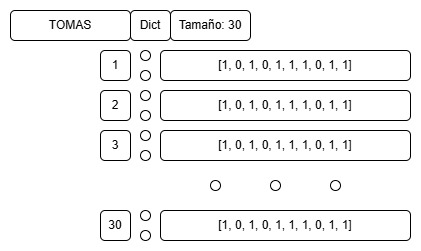

Como estructura de la solución se utiliza una lista de listas. La lista principal está formada por listas de sesiones y, a su vez, cada sesión se corresponde con una lista de tomas.

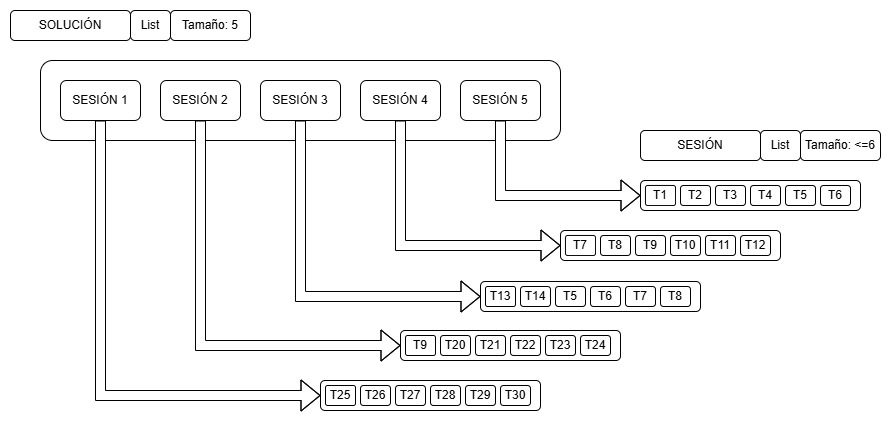

Esta estructura no es óptima, principalmente porque los accesos a los elementos de las listas son más lentos en comparación con otros tipos de datos. No obstante, a nivel de desarrollo resulta más sencilla de implementar que otras alternativas.

Existe otra estructura más adecuada para representar la solución. Esta consiste en un diccionario de tomas con el siguiente formato:
- Clave: número de toma.
- Valor: un entero representado en binario, en el que cada bit representa un actor. Si el bit está a 1, el actor participa en la toma; si está a 0, no participa. Además, la posición del bit indica el número del actor. Es decir, el bit 1 representa al actor 1 y, según su valor, se determina si actúa o no en esa toma.

Siguiendo esta representación binaria, la solución se representaría como una lista de sesiones, donde cada sesión sería una lista de enteros. Esta alternativa resultaría más eficiente que la solución utilizada en este trabajo.

Los accesos a memoria para los enteros son más rápidos y las operaciones a nivel de bits también presentan un mejor rendimiento.

#### 4.- ¿Cuál es la función objetivo?

La función objetivo de nuestro problema es aquella que calcula el gasto total en que incurrimos por los servicios de los actores. Puesto que todos cobran la misma cantidad por día de rodaje e independientemente del número de escenas que graben cada día, se trata del sumatorio de los distintos actores que debe acudir sobre cada día de grabación. 

Matemáticamente: 
$$ Z = \sum_{d \in D} \sum_{a \in A} y_{a,d}$$
donde: 
- D es el conjunto de días de grabación
- A es el conjunto de actores
- $y_{a,d}$ es una variable binaria que vale 1 en caso de que el actor $a$ deba acudir a grabar el día $d$ y 0 en caso contrario

Esta función debe estar sujeta a las restricciones oportunas que garanticen la presencia de los actores correspondientes en las respectivas tomas, así como para restringir el máximo de tomas diarias a 6.

Algorítmicamente, esta función objetivo está codificada dentro de la función *coste_solucion*

#### 5.- ¿Es un problema de maximización o minimización?

Sin duda se trata de un problema de **minimización**. 

Puesto que todos los actores cobran el mismo salario e independientemente del número de tomas que graban en un día de rodaje, y considerando que un día de rodaje por actor cuesta una unidad monetaria, se trata, como se ha expuesto en la cuestión anterior, de minimizar la suma del número de actores diferentes que acuden a rodar sobre los diferentes días de rodaje.

#### 6.- Diseña un algoritmo para resolver el problema por fuerza bruta

El algoritmo de fuerza bruta se encuentra programado en la sección 4 del proyecto. 

Como comentamos allí, no se trata de un enfoque viable para este tamaño del problema, ya que al enfrentarse a la explosión combinatoria de un problema de estas características, **no consigue terminar** de explorar todo el espacio de soluciones del problema.

#### 7.- Calcula la complejidad del algoritmo por fuerza bruta

http://www.lcc.uma.es/~av/Libro/CAP6.pdf
> Vuelta Atrás son de complejidad exponencial por la forma en la que se busca la solución mediante el recorrido en profundidad del árbol. De esta forma estos algoritmos van a ser de un orden de complejidad al menos del número de nodos del árbol que se generen y este número, si no se utilizan restricciones, es de orden de $z^n$ donde z son las posibles opciones que existen en cada etapa, y n el número de etapas que es necesario recorrer hasta construir la solución (esto es, la profundidad del árbol o la longitud de la n-tupla solución).

La complejidad es $O(z^n)$ donde: 
- En este caso, $z$ corresponde con el número de sesiones disponibles, el cual es n/6.
- $n$ es el número de etapas que tiene el árbol hasta encontrar una solución, es decir, el número de tomas que debemos ubicar.

Por tanto, la complejidad resultante obviando constantes multiplicativas sería:
$$O(n^n)$$

#### 8.- Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta por qué crees que mejora el algoritmo por fuerza bruta.

1. **Versión: Ramificación y Poda**

No hemos conseguido desarrollar un algoritmo que finalice la ejecución del problema en un tiempo razonable, ya que la poda aplicada no ha sido suficiente. Aunque hemos obtenido una solución con un coste de 27 (y hemos comprobado mediante el uso de un solver que dicho coste corresponde a una solución óptima), no podemos asegurar que la solución encontrada por nuestro algoritmo sea óptima.

Como nota importante, para "simular" la finalización del algoritmo se ha utilizado un contador del número de tomas que se van planificando. Cada vez que se encuentra una solución mejor que la anterior, este contador se reinicia y el algoritmo continúa buscando nuevas soluciones. Cuando el contador (numero_maximo_tomas_tras_solucion_optima) alcanza el valor de 25.000.000, el algoritmo finaliza independientemente del punto de ejecución en el que se encuentre.

Este procedimiento puede considerarse en cierto modo preparado, ya que se ha utilizado un valor de contador lo suficientemente grande como para permitir alcanzar una solución de coste 27, que posteriormente se ha comprobado que corresponde al coste óptimo.

2. **Versión: GRASP**

Aunque los algoritmos GRASP no garantizan la obtención de la solución óptima, mediante la aplicación de la heurística que hemos implementado conseguimos alcanzar una solución óptima en un tiempo aceptable.
- Construcción de la solución: se realiza en función de ordenación de las tomas (priorizando aquellas con menor coste) y posteriormente se realiza la selección aleatoria de una de las tres mejores tomas candidatas.
- Búsqueda local: se intercambian tomas de forma iterativa hasta encontrar una solución mejor que la actual. Si la nueva solución obtenida tras el intercambio no mejora la solución actual, el cambio se revierte.

#### 9.- Calcula la complejidad del algoritmo

Para nuestro algoritmo de GRASP, su complejidad  se podría calcular mediante el cálculo de sus partes.
$$O(\text{Número Iteraciones} \times (\text{Construir Solución} + \text{Búsqueda Local}))$$
  - **Complejidad de la construcción de la solución**:tenemos dentro de un bucle while (n): un bucle for (n) con un coste_solucion (n) además de un sort (n*logn)), por tanto la complejidad de esta fase es $O(n^3)$.
    
  - **Complejidad de la búsqueda local**: tenemos 4 bucles (dos que recorren las tomas de una sesión (proporcional a 6, constante), dos que recorren las sesiones de la solución (proporcional a n*n)). Dentro del bucle se llama a coste_solucion_actual (proporcional al número de sesiones (proporcional a n/6)), la cual llama a coste_sesion (proporcional al número de actores, que asumimos será proporcional al número de tomas). Por tanto, la complejidad de esta parte es $O(n^4)$.

Por tanto, despreciando términos de menor orden y extrayendo el número de iteraciones que no deja de ser una constante multiplicativa, tenemos que nuestro algoritmo tiene una complejidad polinomial (cuarta): 
$$O(n^4)$$

#### 10.- Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorio.

In [11]:
def generar_datos(n_tomas):
    n_actores = n_tomas // 3 #Mantenemos constante el ratio de actores / tomas
    datos = {}
    
    for t in range(1, n_tomas + 1):
        n_participantes = random.randint(1, int(min(4, n_actores//1.3))) # Calculamos el número de actores por toma 
        elegidos = random.sample(range(n_actores), n_participantes) # Calculamos qué actores

        #Crear estructura de datos
        actores_toma = [1 if i in elegidos else 0 for i in range(n_actores)]
        datos[t] = actores_toma
        
    return datos

In [12]:
escala_tomas = [12, 18, 24, 30]

datos_aleatorios = {escala: generar_datos(escala) for escala in escala_tomas}

#### 11.- Aplica el algoritmo al juego de datos aleatorio generado.

In [13]:
for tamaño, diccionario_tomas in datos_aleatorios.items():
    print ("Resolviendo para tamaño:", tamaño)
    
    #Resolución Solver
    inicio = time.perf_counter()
    coste_solver = solver_comercial(diccionario_tomas, imprimir=False)
    fin = time.perf_counter()
    tiempo_solver = fin - inicio
    print ("Solución solver", coste_solver)

    #Resolución GRASP 
    inicio = time.perf_counter()
    solucion_grasp, coste_grasp = grasp(diccionario_tomas, 1000, imprimir=False)
    fin = time.perf_counter()
    tiempo_grasp= fin - inicio
    print ("Solución GRASP:", coste_grasp)
    if coste_grasp == coste_solver:
        print ("Óptimo alcanzado con éxito\n")
    else: 
        print ("Óptimo no alcanzado\n")

Resolviendo para tamaño: 12
Solución solver 7.0
Solución GRASP: 7
Óptimo alcanzado con éxito

Resolviendo para tamaño: 18
Solución solver 13.0
Solución GRASP: 13
Óptimo alcanzado con éxito

Resolviendo para tamaño: 24
Solución solver 19.0
Solución GRASP: 19
Óptimo alcanzado con éxito

Resolviendo para tamaño: 30
Solución solver 27.0
Solución GRASP: 27
Óptimo alcanzado con éxito



#### 12.- Enumera las referencias que has utilizado (si ha sido necesario) para llevar a cabo el trabajo
- https://gemini.google.com/ (Para asistencia teórica, conceptual y de programación. Se han usado los modelos de la familia Gemini 3 en sus versiones Flash, Pro y DeepMind)
- http://www.lcc.uma.es/~av/Libro/CAP6.pdf (como referencia para la complejidad del algoritmo de fuerza bruta)
- https://calculator.goldsupplier.com/es/bell-numbers-calculator/ (Para el cálculo del número de Bell, pregunta 1)
- https://oeis.org/A148092 (Referencia sobre combinatoria para la resolución de la pregunta 2)

#### 13.- Describe brevemente en unas líneas como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño.

La explosión combinatoria del problema con el número de tomas hace que, si nos planteamos un escalado al alza del tamaño del problema, los enfoques que garanticen el óptimo del problema (ramificación y poda) pasen a ser inviables debido a la vastedad del espacio de soluciones posibles. En este contexto, tendrían que dejar paso necesariamente a las metaheurísticas, como nuestra propuesta de GRASP, que han demostrado rendir, al menos, razonablemente bien.

El punto más interesante creo que estaría en las variaciones del problema ya que el problema tratado, a pesar de exhibir un crecimiento explosivo con el número de tomas, no deja de ser una modelización simplificada de la situación real. La realidad de un rodaje probablemente requeriría una modelización más compleja para capturar todas las aristas de la cuestión. Por ejemplo:
- **Salarios variables**: Por supuesto, una estrella de Hollywood no cobraría lo mismo que un figurante. Esto obligaría al algoritmo a priorizar unas ordenaciones sobre otras (las que favorecieran rodar las escenas que involucren a los actores más caros en menos días)
- **Restricciones en la ordenación de las tomas**: En nuestro caso, todas las ordenaciones son válidas, pero en la realidad de un rodaje es posible que ciertas tomas tuvieran que preceder necesariamente a otras por diversos motivos, complicando así la modelización.
- **Disponibilidad limitada**: podría darse el caso de que determinados actores o determinados recursos necesarios para el rodaje de determinadas tomas tuviesen una disponibilidad total. Asimismo, tomas que implicasen la presencia de determinados elementos posiblemente tendrían que grabarse conjuntamente, compartiendo días de rodaje.

## 9.- Anexo: Prompts usados durante la resolución del proyecto<a id='9-prompts'>

 #### Cálculo de la secuencia A148092 de la OEIS

> *Responde como un experto en Combinatoria. Genera un script de Python para calcular cuántas formas hay de ordenar n elementos en subconjuntos de un máximo de k elementos. Los subconjuntos no tienen por qué tener un número determinado de elementos ni ser todos iguales. Además no importa el orden.*

#### Codificación del Solver de Google OR-Tools

> *Actúa como un programador experto en algoritmia de optimización de problemas. Devuélveme el código de python necesario para resolver el siguiente problema:*
*Problema de asignación de actores a 30 tomas de rodaje. Cada actor cobra por día que va a rodar. Cada día se pueden grabar cómo máximo 6 tomas. El objetivo es minimizar el coste de la película (cada actor cobra 1 unidad por día de rodaje, independientemente de las tomas que grabe)*

#### Codificación del Brunch & Bound con garantía de convergencia

> *Actúa como un programador experto en algoritmia de optimización de problemas. Programa un algoritmo de Branch & Bound para resolver el Talent Scheduling Problem (30 tomas, 10 actores, máximo 6 tomas/día), implementando los siguientes requisitos técnicos: utiliza bitmasks para mejorar la eficiencia. Implementa un Lower Bound eficiente que permita una poda agresiva del espacio de soluciones. Aplica ruptura de la simetría para no explorar soluciones redundantes. Ordena las tomas mediante una heurística Hardest First.*

#### Revisión de código GRASP: 
Tras la realización del algoritmo se ha solicitado que revise el algoritmo. Respuesta a nivel estructura estaba bien, pero indica que falta añadir el alfa para hacer el LRC más adaptativo.
> *Necesito que me hagas una auditoria de codigo. Me puedes decir si este algoritmo está bien hecho? si se cumple el algoritmo GRASP al 100%? o como se podría adaptar parea que sea más GRASP?*